[*********************100%***********************]  22 of 22 completed


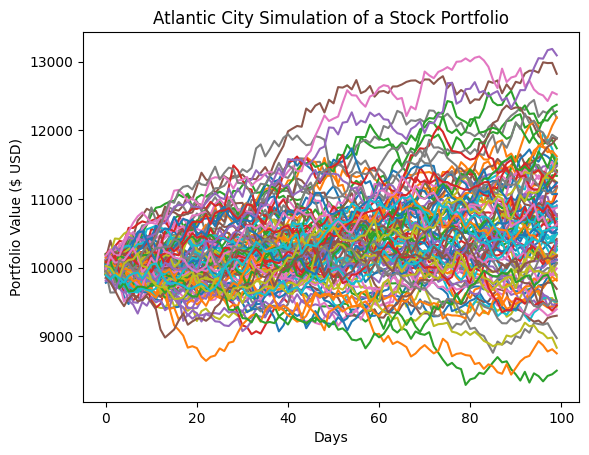

In [1]:
"""
@author: getTomsKnowledge
@date: 10/12/2024
@summary: Monte Carlo simulation of a Stock Portfolio based on \
QuantPy's video found here: https://www.youtube.com/watch?v=6-dhdMDiYWQ
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf

# import data
def get_data(stocks, start, end):
  stockData = yf.download(stocks, start, end)
  stockData = stockData["Close"]
  returns = stockData.pct_change()
  meanReturns = returns.mean()
  covMatrix = returns.cov()
  return meanReturns, covMatrix

stockList = ['ABBNY', 'BALL', 'BP', 'BKD', 'GLW', 'EW', 'F', \
            'IBM', 'IP', 'KHC', 'MBLY', 'MS', 'NOK', 'ORCL', \
            'PKE', 'PFE', 'IOT', 'SNOW', 'SPR', 'KO', 'TSN', \
             'UAL']

# Space Stocks stockList = ['BALL', 'SPCE', 'RKLB', 'ASTS', 'SATS']


#stocks = [stock + '.nyse' for stock in stockList]
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=300)
meanReturns, covMatrix = get_data(stockList, startDate, endDate)

# print(meanReturns) - Sanity Check #1

weights = np.random.random(len(meanReturns))
weights /= np.sum(weights)
# print(weights) - Sanity Check #2

# Atlantic City Method
ac_sims = 100 # number of simulations
T = 100 # timeframe in days

meanM = np.full(shape=(T, len(weights)), fill_value=meanReturns)
meanM = meanM.T

portfolio_sims = np.full(shape=(T, ac_sims), fill_value=0.0)
initialPortfolio = 10000 # initial investment

for m in range(0, ac_sims):
  # AC loops:
  Z = np.random.normal(size=(T, len(weights)))
  L = np.linalg.cholesky(covMatrix)
  dailyReturns = meanM + np.inner(L,Z)
  portfolio_sims[:,m] = np.cumprod(np.inner(weights, dailyReturns.T)+1)*initialPortfolio

plt.plot(portfolio_sims)
plt.ylabel('Portfolio Value ($ USD)')
plt.xlabel('Days')
plt.title('Atlantic City Simulation of a Stock Portfolio')
plt.show()

In [ ]:
yf.download(['LVMUY'], startDate, endDate)

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-12-18,161.800003,162.500000,160.970001,162.139999,160.605103,150300
2023-12-19,162.339996,164.149994,162.279999,163.869995,162.318726,100100
2023-12-20,163.350006,164.300003,161.449997,161.669998,160.139557,188200
2023-12-21,163.070007,164.240005,162.000000,164.240005,162.685226,141700
2023-12-22,163.229996,163.320007,161.559998,162.380005,160.842834,105300
...,...,...,...,...,...,...
2024-10-07,147.979996,149.990005,147.929993,148.929993,148.929993,280900
2024-10-08,144.089996,144.779999,142.809998,144.679993,144.679993,196200
2024-10-09,144.000000,144.699997,142.710007,144.039993,144.039993,296100


In [ ]:
pd.rolling_mean()